# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

**Dataset yang digunakan:** Pima Indians Diabetes Dataset

Dataset ini berisi data medis 768 pasien perempuan keturunan Pima Indian yang
digunakan untuk memprediksi apakah seorang pasien berisiko menderita diabetes
(klasifikasi biner) berdasarkan 8 fitur (jumlah kehamilan, kadar glukosa,
tekanan darah, ketebalan kulit, kadar insulin, BMI, riwayat keturunan diabetes,
dan usia). Sumber: UCI Machine Learning Repository (dicerminkan di GitHub).

**Nama:** Muhammad Ainur Rofal Achsony

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import os

sns.set_style("whitegrid")
%matplotlib inline

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Dataset diambil langsung dari raw GitHub sehingga notebook ini bisa dijalankan
# di Colab tanpa perlu upload manual atau mount Google Drive.
DATASET_URL = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"

df = pd.read_csv(DATASET_URL)
print("Shape dataset:", df.shape)
df.head()

Shape dataset: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

### 4.1 Cek Missing Value dan Nilai Tidak Wajar
Pada dataset ini, nilai `0` pada kolom `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, dan `BMI` secara medis tidak mungkin terjadi pada manusia hidup, sehingga nilai tersebut sebenarnya merepresentasikan *missing value* yang tersembunyi.

In [5]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in zero_cols:
    n_zero = (df[col] == 0).sum()
    print(f"{col}: {n_zero} nilai 0 ({n_zero/len(df)*100:.1f}%)")

Glucose: 5 nilai 0 (0.7%)
BloodPressure: 35 nilai 0 (4.6%)
SkinThickness: 227 nilai 0 (29.6%)
Insulin: 374 nilai 0 (48.7%)
BMI: 11 nilai 0 (1.4%)


In [6]:
print("Missing value asli (NaN):")
print(df.isnull().sum())
print("\nJumlah duplikat baris:", df.duplicated().sum())

Missing value asli (NaN):
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Jumlah duplikat baris: 0


### 4.2 Distribusi Target (Outcome)

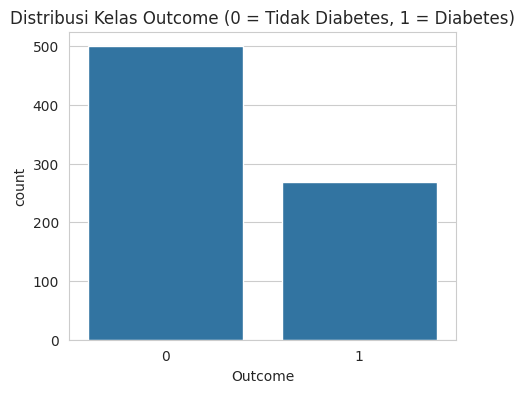

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


In [7]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="Outcome")
plt.title("Distribusi Kelas Outcome (0 = Tidak Diabetes, 1 = Diabetes)")
plt.show()
print(df["Outcome"].value_counts(normalize=True))

### 4.3 Distribusi Setiap Fitur

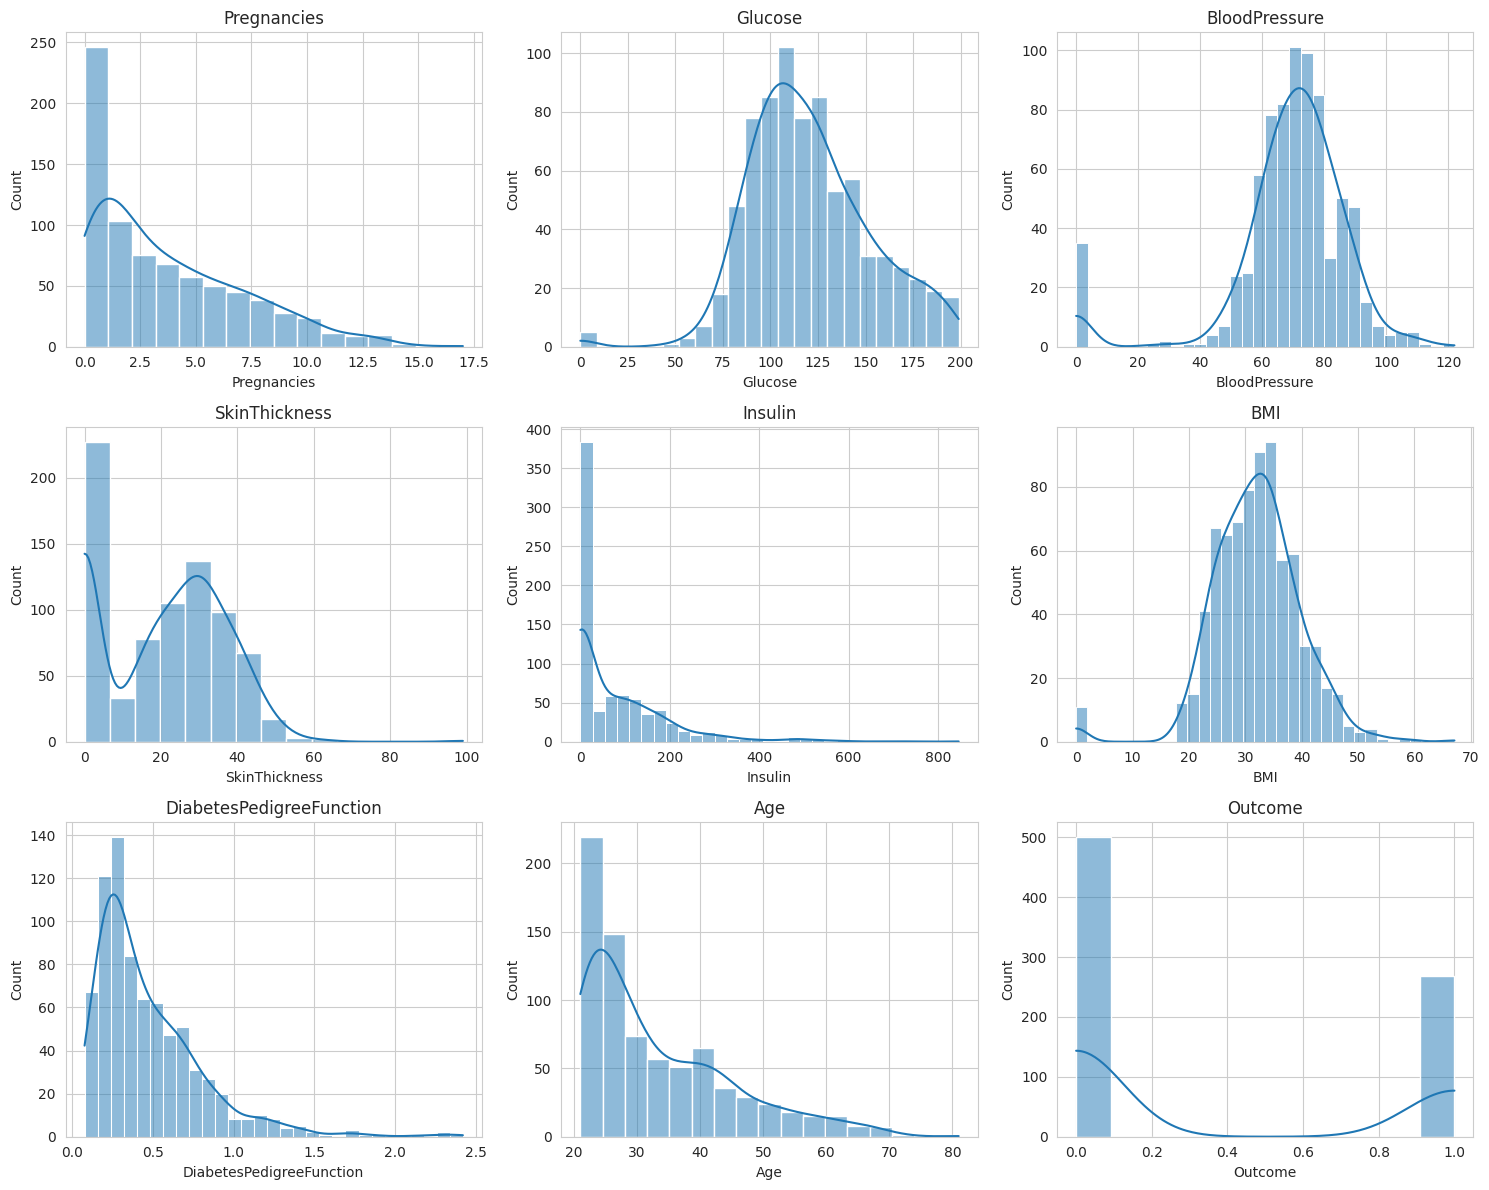

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flatten(), df.columns):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 4.4 Korelasi Antar Fitur

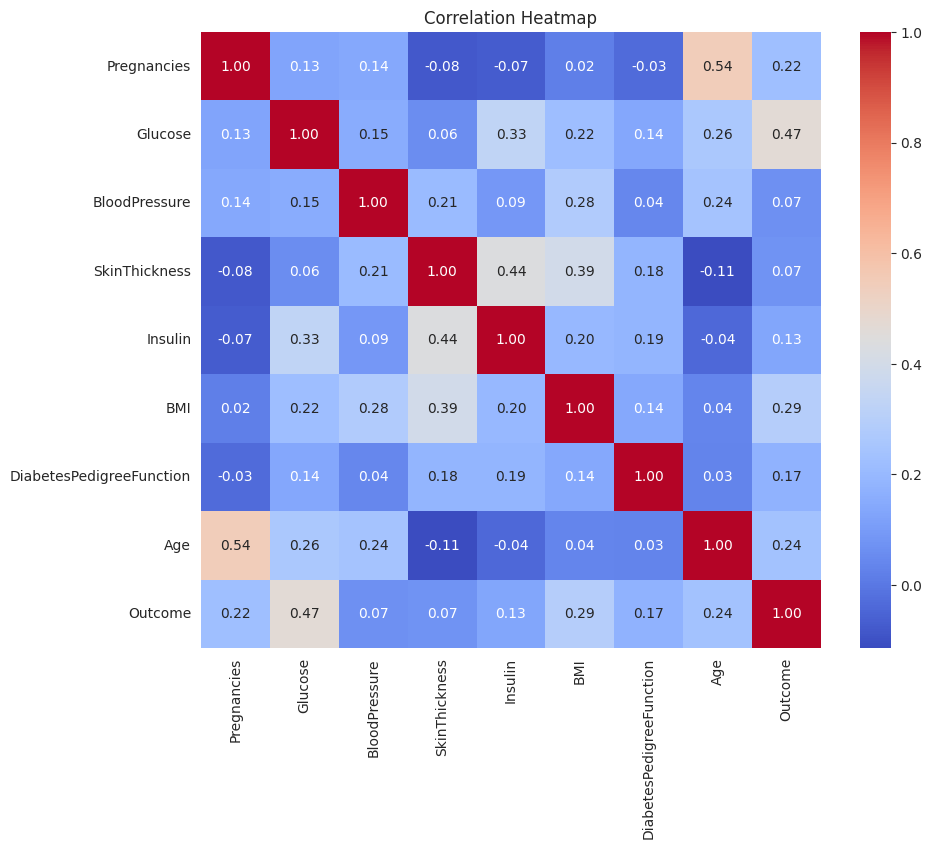

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### 4.5 Deteksi Outlier (Boxplot)

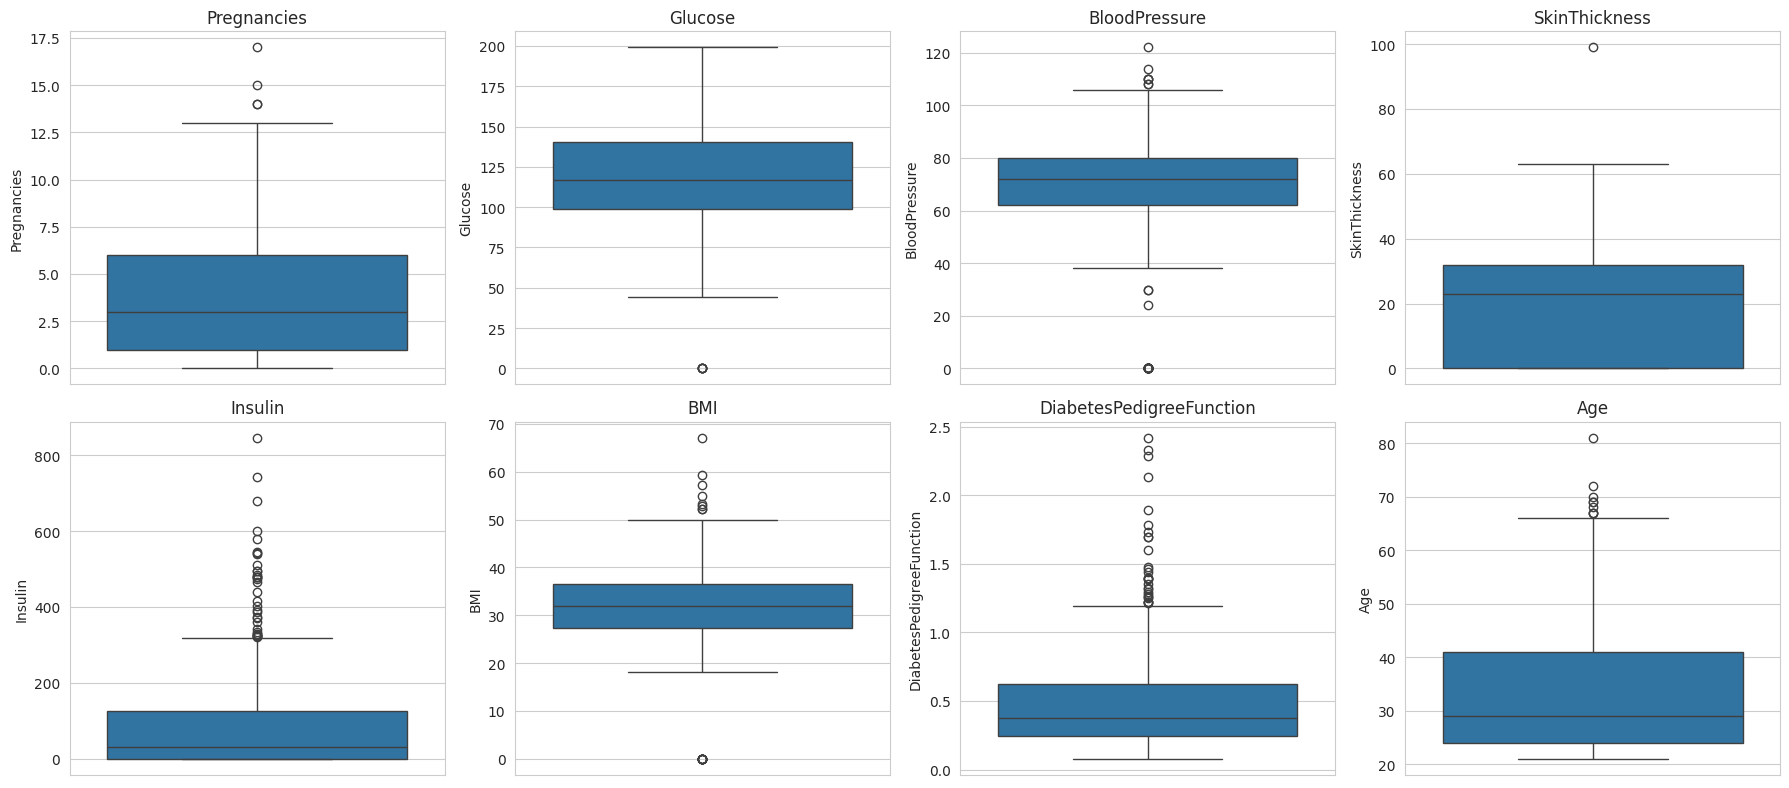

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
feature_cols = [c for c in df.columns if c != "Outcome"]
for ax, col in zip(axes.flatten(), feature_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

### 5.1 Menangani Missing Value Tersembunyi (nilai 0 -> median)

In [11]:
df_clean = df.copy()
for col in zero_cols:
    df_clean[col] = df_clean[col].replace(0, np.nan)
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Setelah imputasi missing value:")
df_clean[zero_cols].describe()

Setelah imputasi missing value:


,Glucose,BloodPressure,SkinThickness,Insulin,BMI
count,768.000000,768.000000,768.000000,768.000000,768.000000
mean,121.656250,72.386719,29.108073,140.671875,32.455208
std,30.438286,12.096642,8.791221,86.383060,6.875177
min,44.000000,24.000000,7.000000,14.000000,18.200000
25%,99.750000,64.000000,25.000000,121.500000,27.500000
50%,117.000000,72.000000,29.000000,125.000000,32.300000
75%,140.250000,80.000000,32.000000,127.250000,36.600000
max,199.000000,122.000000,99.000000,846.000000,67.100000


### 5.2 Menghapus Data Duplikat

In [12]:
before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
after = df_clean.shape[0]
print(f"Baris sebelum: {before}, setelah hapus duplikat: {after} (terhapus {before-after})")

Baris sebelum: 768, setelah hapus duplikat: 768 (terhapus 0)


### 5.3 Deteksi & Penanganan Outlier (IQR)
Outlier ekstrem dibuang hanya pada kolom `BloodPressure` dan `BMI`, karena
kolom lain (`Insulin`, `SkinThickness`) memiliki proporsi missing value yang
sangat besar sehingga distribusinya menjadi terlalu terpampat setelah
imputasi median dan berisiko salah membuang data valid jika ikut difilter
dengan metode IQR.

In [13]:
def remove_outliers_iqr(data, cols):
    data = data.copy()
    for col in cols:
        q1, q3 = data[col].quantile(0.25), data[col].quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
        data = data[(data[col] >= lower) & (data[col] <= upper)]
    return data

before = df_clean.shape[0]
df_clean = remove_outliers_iqr(df_clean, ["BloodPressure", "BMI"])
after = df_clean.shape[0]
print(f"Baris sebelum: {before}, setelah buang outlier: {after} (terbuang {before-after})")

Baris sebelum: 768, setelah buang outlier: 747 (terbuang 21)


### 5.4 Split Data Train & Test

In [14]:
X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (597, 8) | X_test: (150, 8)


### 5.5 Standarisasi Fitur (StandardScaler)
Semua fitur numerik memiliki skala yang sangat berbeda (misalnya `Age` vs `DiabetesPedigreeFunction`), sehingga perlu distandarisasi agar model tidak bias terhadap fitur dengan rentang nilai yang lebih besar.

In [15]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

X_train_scaled.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,5.970000e+02,5.970000e+02,5.970000e+02,5.970000e+02,5.970000e+02,5.970000e+02,5.970000e+02,5.970000e+02
mean,-5.950944e-18,-2.142340e-16,-2.558906e-16,-1.666264e-16,9.819058e-17,4.998793e-16,-4.165661e-16,1.941496e-16
std,1.000839e+00,1.000839e+00,1.000839e+00,1.000839e+00,1.000839e+00,1.000839e+00,1.000839e+00,1.000839e+00
min,-1.140324e+00,-2.542842e+00,-2.945615e+00,-2.418108e+00,-1.411283e+00,-2.213431e+00,-1.164471e+00,-1.033065e+00
25%,-8.422617e-01,-7.368977e-01,-7.302578e-01,-4.726956e-01,-2.317955e-01,-7.382835e-01,-6.897102e-01,-7.747266e-01
50%,-2.461381e-01,-1.458615e-01,8.194720e-03,-1.495144e-02,-1.756295e-01,-7.097364e-04,-2.980326e-01,-3.441627e-01
75%,6.480473e-01,6.093514e-01,7.466472e-01,3.283567e-01,-1.643962e-01,6.740918e-01,3.874032e-01,6.030780e-01
max,3.926727e+00,2.546637e+00,2.962005e+00,7.995571e+00,7.923515e+00,2.714190e+00,5.514819e+00,4.133702e+00


### 5.6 Menyimpan Dataset Siap Latih

In [16]:
os.makedirs("diabetes_preprocessing", exist_ok=True)

train_df = X_train_scaled.copy()
train_df["Outcome"] = y_train.values
test_df = X_test_scaled.copy()
test_df["Outcome"] = y_test.values

train_df.to_csv("diabetes_preprocessing/train.csv", index=False)
test_df.to_csv("diabetes_preprocessing/test.csv", index=False)
joblib.dump(scaler, "diabetes_preprocessing/scaler.joblib")

print("Dataset siap latih berhasil disimpan di folder diabetes_preprocessing/")
print("Train:", train_df.shape, "| Test:", test_df.shape)

Dataset siap latih berhasil disimpan di folder diabetes_preprocessing/
Train: (597, 9) | Test: (150, 9)


## Kesimpulan

- Dataset Pima Indians Diabetes memiliki 768 baris dan 9 kolom, dengan proporsi kelas tidak seimbang (~65% tidak diabetes, ~35% diabetes).
- Kolom `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, dan `BMI` mengandung nilai 0 yang merupakan missing value tersembunyi dan telah diimputasi dengan median.
- Tidak ditemukan baris duplikat pada dataset ini.
- Outlier ekstrem pada `BloodPressure` dan `BMI` dibuang menggunakan metode IQR.
- Data telah displit 80:20 (stratified) dan distandarisasi menggunakan `StandardScaler`.
- Tahapan-tahapan di atas selanjutnya dikonversi menjadi fungsi otomatis pada file `automate_Muhammad-Ainur-Rofal-Achsony.py`.